Analyze the observation to identify unusal spectral features that may warrant further investigation 


Blimpy is python package designed for working with radio astronomy data

Waterfall is the class we import to read the .h5 file which gives access to meta data + spectral data


In [3]:
from blimpy import Waterfall

file_path = "../data/raw/spliced_blc0001020304050607_guppi_57635_35657_Gj144_0005.gpuspec.0002.h5"

obs = Waterfall(file_path)

obs.info()


--- File Info ---
DIMENSION_LABELS :   ['frequency' 'feed_id' 'time']
        az_start :                              0.0
       data_type :                                1
            fch1 :                2802.83203125 MHz
            foff :         -0.00286102294921875 MHz
      machine_id :                               20
           nbits :                               32
          nchans :                           351232
            nifs :                                1
     source_name :                            Gj144
         src_dej :                     -9:13:11.007
         src_raj :                       3:32:54.68
    telescope_id :                                6
           tsamp :               1.0737418239999998
   tstart (ISOT) :          2016-09-04T09:54:17.000
    tstart (MJD) :                57635.41269675926
        za_start :                              0.0

Num ints in file :                              273
      File shape :       (273, np.int64(1), 

SPACE BETWEEN FREQUENCIES<br>
foff ≈ 2.861 kHz<br>

SPACE BETWEEN TIMES<br>
tsamp ≈ 1.074 seconds<br>

RA  = 3:32:54.68 <br>
DEC = -9:13:11.007 <br>

RA = Right Ascension<br>
DEC = Declination<br>

Earth map             Sky map<br>

longitude    ←→       right ascension<br>
latitude     ←→       declination

ISOT = human-friendly timestamp<br>
MJD  = astronomy-friendly numerical timestamp

VERY VERY IMPORTANT


TARGET<br>
source_name = GJ144<br>

TIME RESOLUTION<br>
tsamp = 1.074 seconds<br>

NUMBER OF FREQUENCIES<br>
nchans = 351,232<br>

STARTING FREQUENCY<br>
fch1 = 2802.832 MHz<br>

FREQUENCY RESOLUTION/DIRECTION<br>
foff = -0.002861 MHz ≈ -2.861 kHz<br>

OBSERVATION START<br>
2016-09-04 09:54:17 UTC <br>

start → when the observation began<br>
tsamp → time interval associated with successive samples/integrations<br>

In [1]:
%matplotlib inline

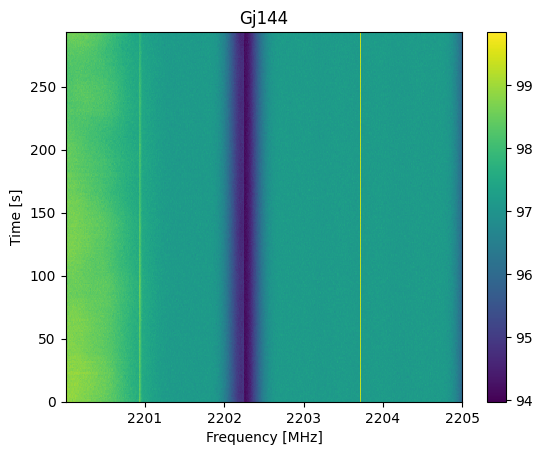

In [5]:
import matplotlib.pyplot as plt

obs.plot_waterfall(f_start=2200, f_stop=2205)
plt.show()

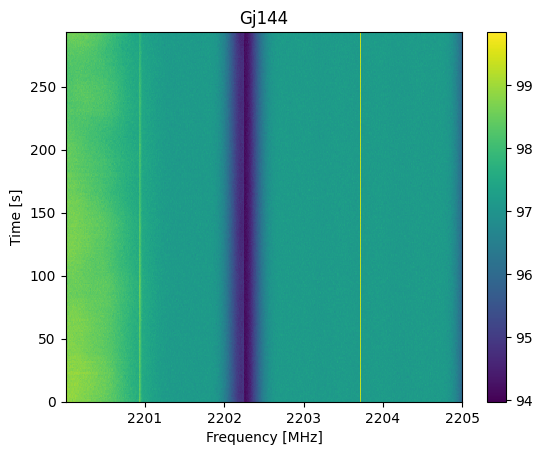

In [6]:
plt.close('all')

obs.plot_waterfall(
    f_start=2200,
    f_stop=2205
)

plt.show()

Color represents the measured power/intensity at that point. Lower power is darker higher power is brighter 

It visualizes the observation as a time-frequency waterfall over a selected 5 MHz frequency window, with color representing measured power.

In [7]:
import numpy as np

signal = obs.data[:, 0, :]

print(signal.shape)

(273, 351232)


obs.data[:, 0, :] selects all time integrations and all frequency channels from feed/IF index 0, removing the unnecessary singleton feed dimension.

273 time samples<br>
351,232 frequency channels

In [8]:
mean_power = np.mean(signal, axis=0)

print(mean_power.shape)

(351232,)


np.mean(signal, axis=0) averages the power measurements across all 273 time integrations for each frequency channel, producing one mean-power value per frequency channel.


In [9]:
freqs, _ = obs.grab_data()

print(freqs.shape)
print(freqs[:5])

(351232,)
[2802.83203125 2802.82917023 2802.8263092  2802.82344818 2802.82058716]


mean_power contains the averaged power measurement for each channel, while  <br>
freqs contains the actual frequency in MHz associated with each channel.

<br>
grab_data(<br>
    f_start=None,<br>
    f_stop=None,<br>
    t_start=None,<br>
    t_stop=None,<br>
    if_id=0<br>
)
<br>


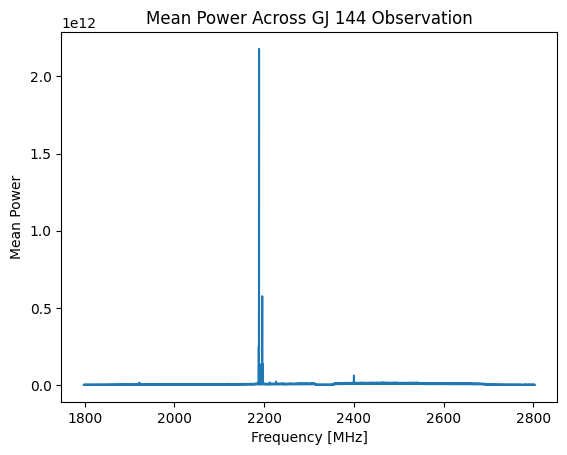

In [10]:
plt.plot(freqs, mean_power)
plt.xlabel("Frequency [MHz]")
plt.ylabel("Mean Power")
plt.title("Mean Power Across GJ 144 Observation")
plt.show()

In [11]:
freqs, data = obs.grab_data()

print("freqs:", freqs.shape)
print("data:", data.shape)

freqs: (351232,)
data: (273, 351232)


In [12]:
mask = (freqs >= 2200) & (freqs <= 2205)

zoom_freqs = freqs[mask]
zoom_power = mean_power[mask]

In [13]:
print(zoom_freqs.shape)
print(zoom_power.shape)

print(zoom_freqs.min())
print(zoom_freqs.max())

(1748,)
(1748,)
2200.0001907348633
2204.9983978271484


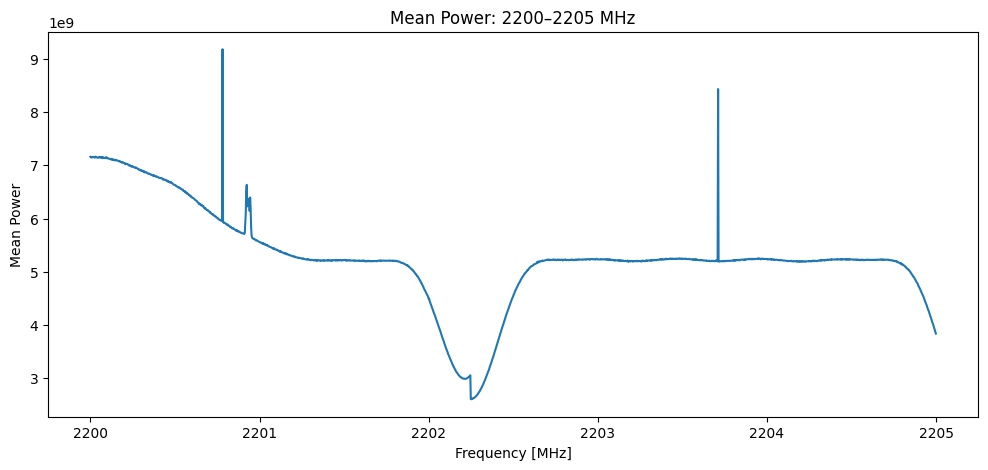

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(zoom_freqs, zoom_power)

plt.xlabel("Frequency [MHz]")
plt.ylabel("Mean Power")
plt.title("Mean Power: 2200–2205 MHz")

plt.show()

In [15]:
mean_zoom_power = np.mean(zoom_power)

print(mean_zoom_power)

5.2748626e+09


In [16]:
median_zoom_power = np.median(zoom_power)

print("Mean:  ", mean_zoom_power)
print("Median:", median_zoom_power)

Mean:   5.2748626e+09
Median: 5.220566e+09


In [17]:
std_zoom_power = np.std(zoom_power)

print("Mean:", mean_zoom_power)
print("Median:", median_zoom_power)
print("Standard deviation:", std_zoom_power)

Mean: 5.2748626e+09
Median: 5.220566e+09
Standard deviation: 8.7764966e+08


Finding most extreme standardized power values and what their related std's are above and below the mean


In [18]:
z_scores = (zoom_power - mean_zoom_power) / std_zoom_power
print(z_scores.shape)
print("Highest z-score:", np.max(z_scores))
print("Lowest z-score:", np.min(z_scores))


(1748,)
Highest z-score: 4.45076
Lowest z-score: -3.0429387


Find where the strongest positive deviation occurs, then use that index to determine its corresponding frequency.

In [19]:
max_index = np.argmax(z_scores)
#index of largest z_score
print(max_index)

print(zoom_freqs[max_index])
print(zoom_power[max_index])
print(z_scores[max_index])

1474
2200.78125
9.18107e+09
4.45076


In [20]:
min_index = np.argmin(z_scores)
#index of smalles z_score
print(min_index)

print(zoom_freqs[min_index])
print(zoom_power[min_index])
print(z_scores[min_index])

960
2202.2518157958984
2.6042284e+09
-3.0429387


Finding all frequency channels that meet an outlier threshold 


<br>
boolean mask to count the amount of stds above and below the mean

In [21]:
z_mask = np.abs(z_scores) >= 3

print(np.sum(z_mask))


11


Use boolean mask to extract the actual anomaly candidates

In [22]:
anomaly_freqs = zoom_freqs[z_mask]
#frequencies related to z_mask = True
anomaly_power = zoom_power[z_mask]
#power values for anomalous channels
anomaly_z = z_scores[z_mask]
#the z_scores 

print(anomaly_freqs)
print(anomaly_power)
print(anomaly_z)

[2203.7109375  2202.27184296 2202.26898193 2202.26612091 2202.26325989
 2202.26039886 2202.25753784 2202.25467682 2202.2518158  2202.24895477
 2200.78125   ]
[8.4321336e+09 2.6391721e+09 2.6302300e+09 2.6284925e+09 2.6205814e+09
 2.6135137e+09 2.6156119e+09 2.6062190e+09 2.6042284e+09 2.6070702e+09
 9.1810703e+09]
[ 3.5974162 -3.0031238 -3.0133123 -3.015292  -3.024306  -3.0323591
 -3.0299683 -3.0406706 -3.0429387 -3.0397007  4.45076  ]


In [23]:
#pulling foff from metadata in header
#foff = frequency offset between adjacent channels

channel_spacing = abs(obs.header["foff"])

print(channel_spacing)

0.00286102294921875


Compare differences between anomalous frequencies to the expected channel spacing. Adjacent anomalies separated by about foff belong to the same contiguous frequency region; larger gaps indicate a break between regions.

In [24]:
freq_diffs = np.abs(np.diff(anomaly_freqs))

print(freq_diffs)

[1.43909454 0.00286102 0.00286102 0.00286102 0.00286102 0.00286102
 0.00286102 0.00286102 0.00286102 1.46770477]


In [25]:
print(anomaly_freqs.shape)
print(freq_diffs.shape)

(11,)
(10,)


If the gap between two anomalous frequencies is more than 1.5× the normal channel spacing, consider that a break between anomaly groups.

In [26]:
breaks = freq_diffs > channel_spacing * 1.5

print(breaks)

[ True False False False False False False False False  True]


In [27]:
print(np.sum(breaks))

2


np.where(breaks)[0] finds the positions of large frequency gaps. Add 1 because each gap occurs between two anomaly frequencies, and we want the split index to point to the first element of the new group

In [28]:
#find index of breaks
print(np.where(breaks))

(array([0, 9]),)


break_indices identifies the element BEFORE the gap. np.split() needs the position AFTER that element.

In [29]:
break_indices = np.where(breaks)[0]

print(break_indices)

[0 9]


In [30]:
#adding 1 to signify where we want the split at in the list 
split_indices = break_indices + 1

print(split_indices)

[ 1 10]


In [31]:
#create multiple arrays based on the split_indices
features = np.split(anomaly_freqs, split_indices)
print(features)

[array([2203.7109375]), array([2202.27184296, 2202.26898193, 2202.26612091, 2202.26325989,
       2202.26039886, 2202.25753784, 2202.25467682, 2202.2518158 ,
       2202.24895477]), array([2200.78125])]


In [32]:
for feature in features:
    # number of frequency channels in candidate feature
    print("Channels:", len(feature))
    #center of frequency 
    print("Center frequency:", np.mean(feature))
    # frequency span of candidate feature
    print("Bandwidth:", max(feature) - min(feature))

Channels: 1
Center frequency: 2203.7109375
Bandwidth: 0.0
Channels: 9
Center frequency: 2202.260398864746
Bandwidth: 0.02288818359375
Channels: 1
Center frequency: 2200.78125
Bandwidth: 0.0


In [33]:
#Split the anomalous z-scores at exactly the same boundaries we used to split the anomalous frequencies.
feature_z = np.split(anomaly_z, split_indices)
print(feature_z)

[array([3.5974162], dtype=float32), array([-3.0031238, -3.0133123, -3.015292 , -3.024306 , -3.0323591,
       -3.0299683, -3.0406706, -3.0429387, -3.0397007], dtype=float32), array([4.45076], dtype=float32)]


In [34]:
for z in feature_z:
    max_z_index = np.argmax(np.abs(z))
    max_z = z[max_z_index]

    print("Max Absolute Value:", abs(max_z))
    print("Direction:", "Negative" if max_z < 0 else "Positive")
    

Max Absolute Value: 3.5974162
Direction: Positive
Max Absolute Value: 3.0429387
Direction: Negative
Max Absolute Value: 4.45076
Direction: Positive


In [35]:
candidate_records = []

for feature, z in zip(features, feature_z):
    channel_count = len(feature)
    center_frequency = np.mean(feature)
    frequency_span = max(feature) - min(feature)
    strongest_z_index = np.argmax(abs(z))
    max_z = z[strongest_z_index]
    signed_strongest_z = "Negative" if max_z < 0 else "Positive"

    candidate_records.append({"channel_count":channel_count,
                            "center_frequency":center_frequency,
                            "frequency_span":frequency_span,
                            "strongest_z":max_z,
                            "signed_strongest_z":signed_strongest_z
                              })

print(candidate_records)

[{'channel_count': 1, 'center_frequency': np.float64(2203.7109375), 'frequency_span': np.float64(0.0), 'strongest_z': np.float32(3.5974162), 'signed_strongest_z': 'Positive'}, {'channel_count': 9, 'center_frequency': np.float64(2202.260398864746), 'frequency_span': np.float64(0.02288818359375), 'strongest_z': np.float32(-3.0429387), 'signed_strongest_z': 'Negative'}, {'channel_count': 1, 'center_frequency': np.float64(2200.78125), 'frequency_span': np.float64(0.0), 'strongest_z': np.float32(4.45076), 'signed_strongest_z': 'Positive'}]


In [36]:
import pandas as pd

candidate_df = pd.DataFrame(candidate_records)

print(candidate_df)

   channel_count  center_frequency  frequency_span  strongest_z  \
0              1       2203.710938        0.000000     3.597416   
1              9       2202.260399        0.022888    -3.042939   
2              1       2200.781250        0.000000     4.450760   

  signed_strongest_z  
0           Positive  
1           Negative  
2           Positive  


In [37]:
candidate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   channel_count       3 non-null      int64  
 1   center_frequency    3 non-null      float64
 2   frequency_span      3 non-null      float64
 3   strongest_z         3 non-null      float32
 4   signed_strongest_z  3 non-null      str    
dtypes: float32(1), float64(2), int64(1), str(1)
memory usage: 240.0 bytes


In [38]:
candidate_df.describe()

,channel_count,center_frequency,frequency_span,strongest_z
count,3.000000,3.000000,3.000000,3.000000
mean,3.666667,2202.250862,0.007629,1.668413
std,4.618802,1.464867,0.013214,4.102398
min,1.000000,2200.781250,0.000000,-3.042939
25%,1.000000,2201.520824,0.000000,0.277239
50%,1.000000,2202.260399,0.000000,3.597416
75%,5.000000,2202.985668,0.011444,4.024088
max,9.000000,2203.710938,0.022888,4.450760


In [39]:
candidate_df["signed_strongest_z"].value_counts()

signed_strongest_z
Positive    2
Negative    1
Name: count, dtype: int64

We identified anomalous frequency channels using z-scores, grouped neighboring anomalous channels into candidate spectral features, and extracted characteristics for each candidate. These were then stored as structured records and converted into a pandas DataFrame for further analysis.
